### Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

### Carga de archivos

In [2]:
# df_test = pd.read_csv('test.csv') #sweetviz
# df_train = pd.read_csv('train.csv')
df_sub=pd.read_csv("https://raw.githubusercontent.com/juancmacias/datas/main/DataSet/sample_submission.csv")
df_train=pd.read_csv("https://raw.githubusercontent.com/juancmacias/datas/main/DataSet/train.csv")
df_test=pd.read_csv("https://raw.githubusercontent.com/juancmacias/datas/main/DataSet/test.csv")

### Exploración inicial

In [3]:
df_test.head(10)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
5,188538,Chevrolet,Express 2500 Work Van,2013,99524,Gasoline,285.0HP 4.8L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes
6,188539,Lexus,RX 350 Base,2008,194000,Gasoline,270.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Silver,Gray,None reported,Yes
7,188540,Chevrolet,Impala 1LT,2019,40208,Gasoline,3.8L V6 24V GDI DOHC,6-Speed Automatic,Silver Ice Metallic,Jet Black,None reported,Yes
8,188541,Mercedes-Benz,S-Class S 63 AMG,2016,7600,Gasoline,536.0HP 5.5L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Black,None reported,Yes
9,188542,Genesis,G80 3.3T Sport,2017,63300,Gasoline,365.0HP 3.3L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,None reported,Yes


In [4]:
df_train.head(10)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500
5,5,Audi,A6 2.0T Sport,2018,40950,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,White,–,None reported,Yes,29950
6,6,Audi,A8 L 3.0T,2016,62200,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,None reported,Yes,28500
7,7,Chevrolet,Silverado 1500 1LZ,2016,102604,E85 Flex Fuel,355.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,White,Gray,None reported,Yes,12500
8,8,Ford,F-150 XLT,2020,38352,Gasoline,2.7L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Snowflake White Pearl Metallic,Black,None reported,Yes,62890
9,9,BMW,M4 Base,2015,74850,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Black,Blue,None reported,Yes,4000


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125690 entries, 0 to 125689
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            125690 non-null  int64 
 1   brand         125690 non-null  object
 2   model         125690 non-null  object
 3   model_year    125690 non-null  int64 
 4   milage        125690 non-null  int64 
 5   fuel_type     122307 non-null  object
 6   engine        125690 non-null  object
 7   transmission  125690 non-null  object
 8   ext_col       125690 non-null  object
 9   int_col       125690 non-null  object
 10  accident      124058 non-null  object
 11  clean_title   111451 non-null  object
dtypes: int64(3), object(9)
memory usage: 11.5+ MB


In [7]:
print('La forma del train dataset es', df_train.shape)
print('La forma del test dataset es', df_test.shape , '\n')
print('Rows duplicadas en train dataset :', df_train.duplicated().sum() )
print('Rows duplicadas en test dataset :', df_test.duplicated().sum() , '\n')

La forma del train dataset es (188533, 13)
La forma del test dataset es (125690, 12) 

Rows duplicadas en train dataset : 0
Rows duplicadas en test dataset : 0 



In [8]:
print('>> Estadísticas descriptivas de Train Data \n')
df_train.describe().T

>> Estadísticas descriptivas de Train Data 



,count,mean,std,min,25%,50%,75%,max
id,188533.0,94266.000000,54424.933488,0.0,47133.0,94266.0,141399.0,188532.0
model_year,188533.0,2015.829998,5.660967,1974.0,2013.0,2017.0,2020.0,2024.0
milage,188533.0,65705.295174,49798.158076,100.0,24115.0,57785.0,95400.0,405000.0
price,188533.0,43878.016178,78819.522254,2000.0,17000.0,30825.0,49900.0,2954083.0


In [9]:
print('>> Estadísticas descriptivas de Test Data \n')
df_test.describe().T

>> Estadísticas descriptivas de Test Data 



,count,mean,std,min,25%,50%,75%,max
id,125690.0,251377.500000,36283.722005,188533.0,219955.25,251377.5,282799.75,314222.0
model_year,125690.0,2015.797526,5.673797,1974.0,2013.00,2017.0,2020.00,2024.0
milage,125690.0,66042.581510,50223.858435,100.0,24500.00,57500.0,95798.00,405000.0


### EDA (Exploratory Data Analysis) using Profiler

1.   Elemento de lista
2.   Elemento de lista



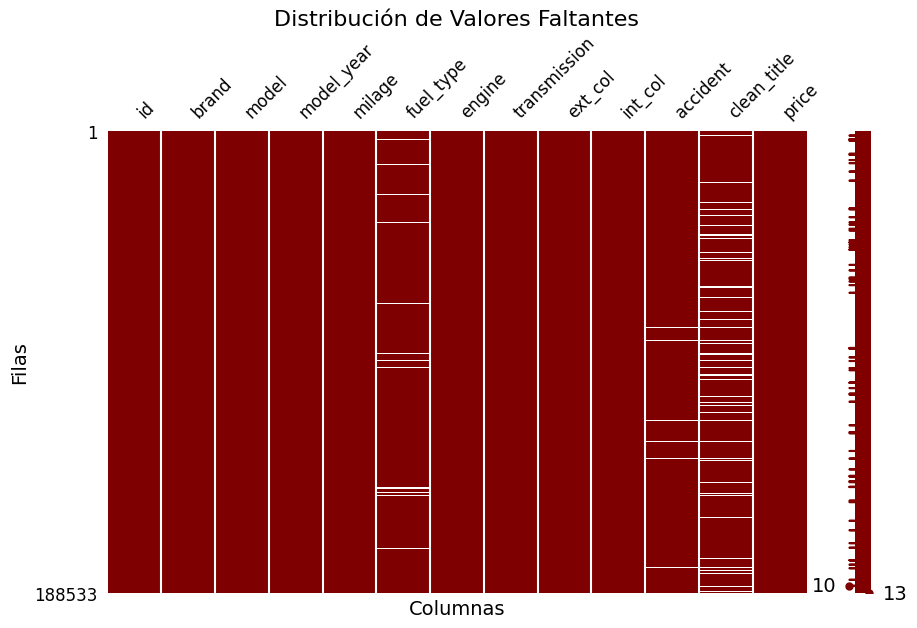

In [10]:
matrix_plot = msno.matrix(df_train, figsize=(10, 6), color=(0.5, 0, 0))
plt.title('Distribución de Valores Faltantes', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Columnas', fontsize=14)
plt.ylabel('Filas', fontsize=14)
plt.show()

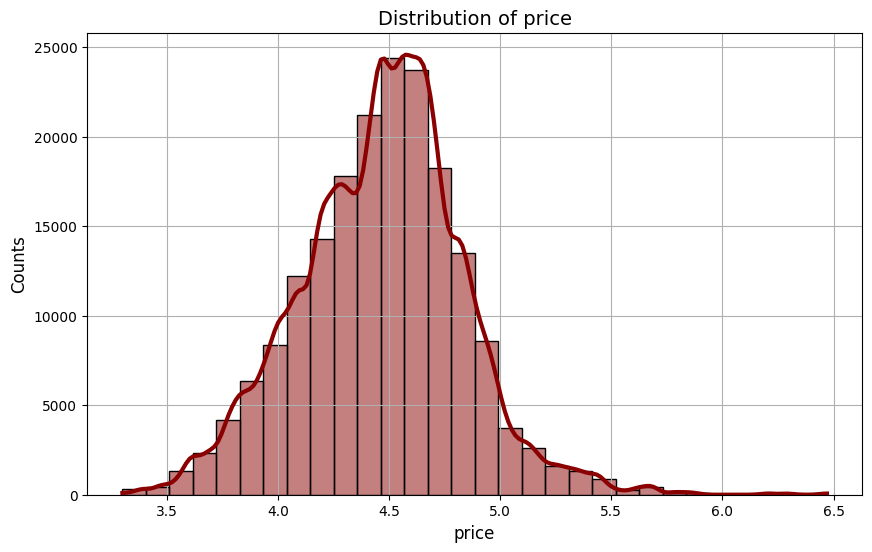

In [11]:
def plot_num_distribution(df, target_column):

    plt.figure(figsize=(10, 6))

    sns.histplot(
        np.log10(df[target_column]),
        stat='count',
        kde=True,
        bins=30,
        color='darkred',
        line_kws = {'lw':3})

    plt.title(f'Distribution of {target_column}', fontsize=14)
    plt.xlabel(target_column, fontsize=12)
    plt.ylabel('Counts', fontsize=12)
    plt.grid(True)
    plt.show()

plot_num_distribution(df_train, 'price')

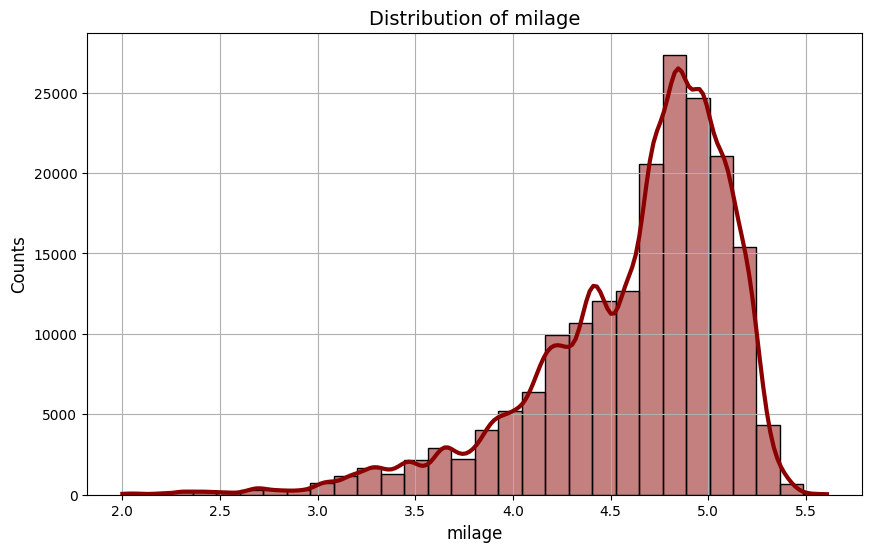

In [12]:
plot_num_distribution(df_train, 'milage')

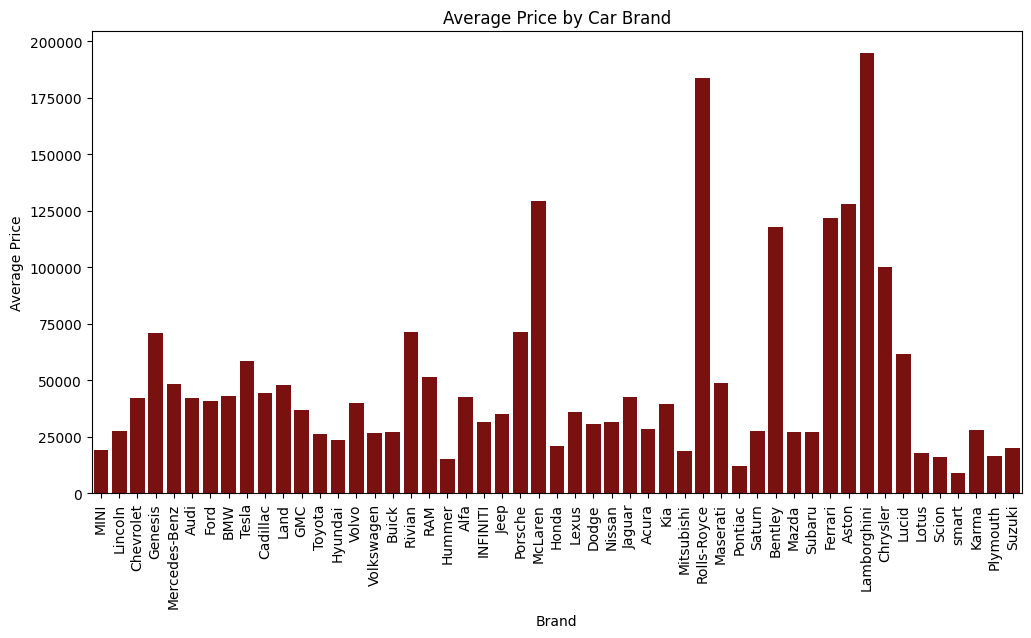

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x='brand', y='price', data=df_train[:10000], errorbar=None, color='darkred',
)
plt.title('Average Price by Car Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()

<ipython-input-14-25fcb7c3cd30>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_train['accident'], x=df_train['price'], palette='Set2',


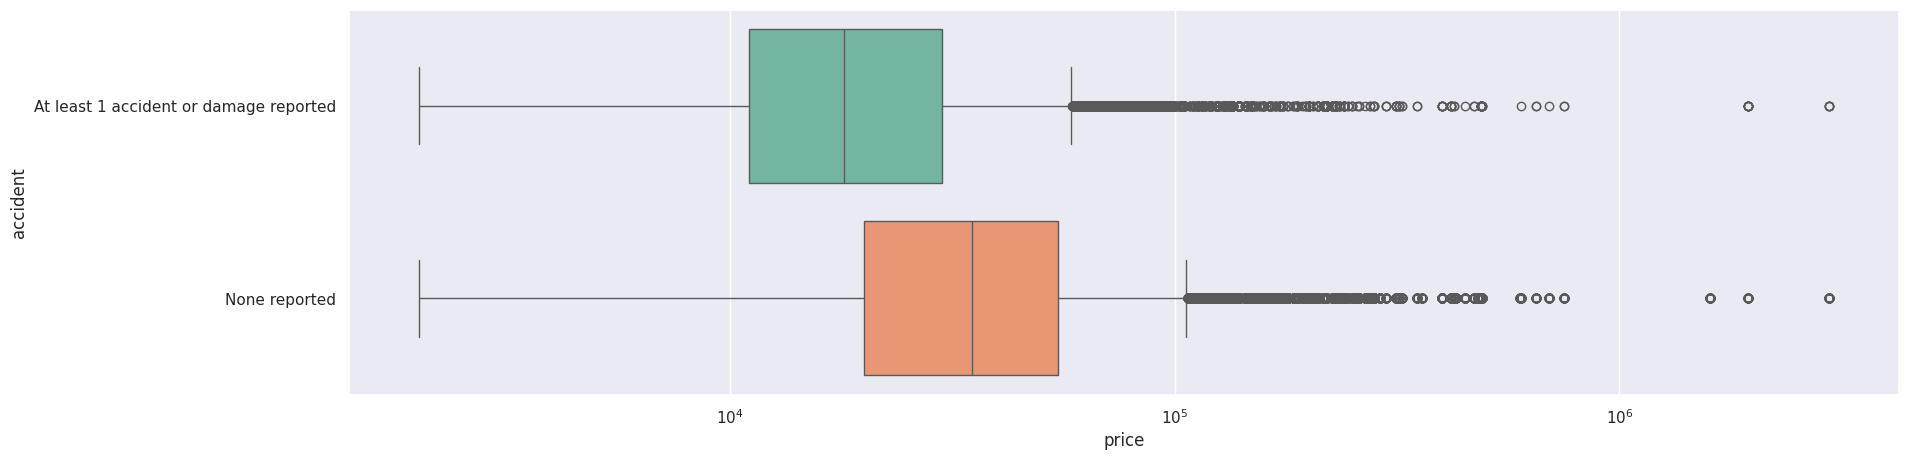

In [14]:
sns.set(rc={'figure.figsize': (20, 5)})
mean_price_order = df_train.groupby('accident')['price'].median().sort_values().index
sns.boxplot(y=df_train['accident'], x=df_train['price'], palette='Set2',
           order=mean_price_order)
plt.xscale('log')

<ipython-input-15-5f0837cd42fc>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_train['fuel_type'], x=df_train['price'], palette='Set2',


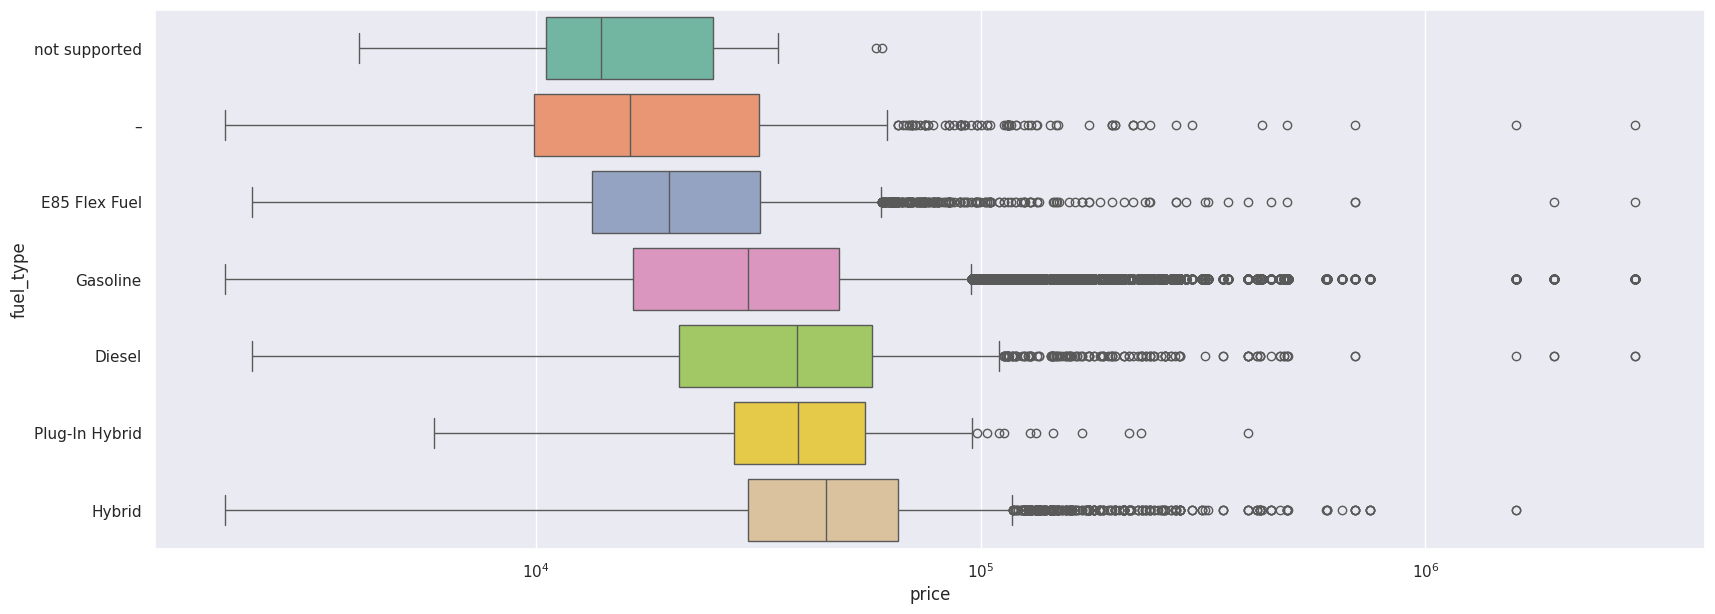

In [15]:
sns.set(rc={'figure.figsize': (20, 7)})
mean_price_order = df_train.groupby('fuel_type')['price'].median().sort_values().index
sns.boxplot(y=df_train['fuel_type'], x=df_train['price'], palette='Set2',
           order=mean_price_order)
plt.xscale('log')

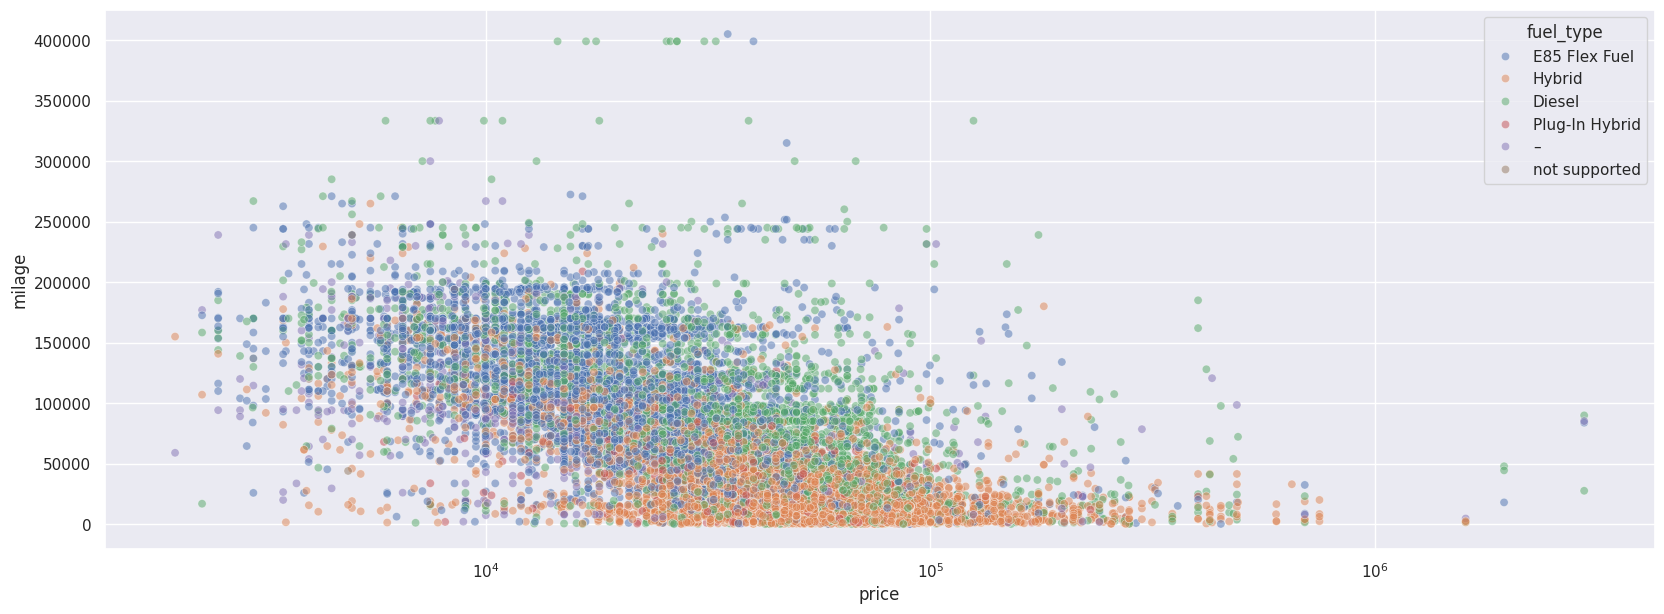

In [16]:
sns.scatterplot(x=df_train[df_train['fuel_type'] != 'Gasoline']['price'],
                y=df_train[df_train['fuel_type'] != 'Gasoline']['milage'],
                hue = df_train[df_train['fuel_type'] != 'Gasoline']['fuel_type'],
                color='grey', alpha=0.5)
plt.xscale('log')

In [17]:
# Función para detectar outliers usando el método IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detectar outliers en variables numéricas importantes
for col in ['model_year', 'milage']:
    outliers, lower, upper = detect_outliers(df_train, col)
    outlier_percentage = (len(outliers) / len(df_train)) * 100

    # Analizar características de los outliers
    if len(outliers) > 0:
        print("\nEstadísticas de outliers:")
        print(outliers[col].describe())

        # Top 5 marcas con más outliers
        top_outlier_brands = outliers['brand'].value_counts().head(5)
        print("\nTop 5 marcas con más outliers:")
        print(top_outlier_brands)




Estadísticas de outliers:
count    5132.000000
mean     1999.746687
std         2.642202
min      1974.000000
25%      1999.000000
50%      2001.000000
75%      2001.000000
max      2002.000000
Name: model_year, dtype: float64

Top 5 marcas con más outliers:
brand
Chevrolet    816
BMW          551
Ford         514
Toyota       491
Jeep         398
Name: count, dtype: int64

Estadísticas de outliers:
count      1766.000000
mean     235158.252548
std       31461.434517
min      202666.000000
25%      212500.000000
50%      229450.000000
75%      245000.000000
max      405000.000000
Name: milage, dtype: float64

Top 5 marcas con más outliers:
brand
Ford         377
Toyota       318
Chevrolet    201
Lexus        112
Dodge        104
Name: count, dtype: int64


### Data cleaning & Feature Engineering

In [18]:
columns_with_en_dash = df_train.columns[df_train.apply(lambda col: (col.astype(str) == "–").any())]
print(columns_with_en_dash)

Index(['fuel_type', 'engine', 'transmission', 'ext_col', 'int_col'], dtype='object')


In [19]:
df_train.replace("–", np.nan, inplace=True)
df_test.replace("–", np.nan, inplace=True)

In [20]:
unique_engine_values = df_train['engine'].unique()
print(unique_engine_values)

['172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel'
 '252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel'
 '320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capability' ...
 '78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel'
 '139.0HP 1.6L 4 Cylinder Engine Plug-In Electric/Gas'
 '313.0HP 2.0L 4 Cylinder Engine Plug-In Electric/Gas']


In [21]:
rows_with_nan_fuel_and_electric = df_train[df_train['fuel_type'].isnull() & df_train['engine'].str.contains('Electric Fuel', case=False, na=False)]
len(rows_with_nan_fuel_and_electric)
rows_with_nan_fuel_and_electric

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
11,11,Tesla,Model S P100D,2015,81500,NaN,Electric Motor Electric Fuel System,1-Speed A/T,Gray,White,None reported,Yes,19000
32,32,Tesla,Model S P100D,2018,30300,NaN,518.0HP Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,64000
52,52,Tesla,Model X 75D,2021,88000,NaN,518.0HP Electric Motor Electric Fuel System,1-Speed A/T,Black,Black,None reported,Yes,53600
161,161,Tesla,Model S Long Range,2021,9500,NaN,670.0HP Electric Motor Electric Fuel System,A/T,White,Beige,None reported,Yes,89999
174,174,Porsche,Taycan Turbo,2023,1794,NaN,Electric Motor Electric Fuel System,2-Speed A/T,Blue,Black,None reported,Yes,83500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188339,188339,Tesla,Model S 100D,2018,28333,NaN,518.0HP Electric Motor Electric Fuel System,1-Speed A/T,Silver,Black,At least 1 accident or damage reported,Yes,49999
188455,188455,Ford,Mustang Mach-E GT,2022,8000,NaN,480.0HP Electric Motor Electric Fuel System,A/T,Orange,White,None reported,Yes,115000
188462,188462,Ford,Mustang Mach-E GT,2023,9000,NaN,480.0HP Electric Motor Electric Fuel System,A/T,Orange,Black,None reported,Yes,85000
188484,188484,Ford,Model X P100D,2018,52000,NaN,534.0HP Electric Motor Electric Fuel System,1-Speed A/T,Gray,Black,None reported,Yes,45000


In [22]:
rows_with_no_fuel_and_electric = df_test[df_test['fuel_type'].isnull() & df_test['engine'].str.contains('Electric Fuel', case=False, na=False)]
len(rows_with_no_fuel_and_electric)

2934

In [23]:
df_train.loc[rows_with_nan_fuel_and_electric.index, 'fuel_type'] = 'Electric'
after_change_count = len(df_train[df_train['fuel_type'] == 'Electric'])
after_change_count

4405

In [24]:
df_test.loc[rows_with_no_fuel_and_electric.index, 'fuel_type'] = 'Electric'
after_change_count = len(df_test[df_test['fuel_type'] == 'Electric'])
after_change_count

2934

In [25]:
unique_engine_values = df_train['clean_title'].unique()
print(unique_engine_values)

['Yes' nan]


In [26]:
unique_engine_values = df_train['accident'].unique()
print(unique_engine_values)

['None reported' 'At least 1 accident or damage reported' nan]


In [27]:
# Extraer potencia y tamaño del motor desde 'engine'
df_train["horsepower"] = df_train["engine"].str.extract(r'(\d+\.?\d*)HP').astype(float)
df_train["engine_L"] = df_train["engine"].str.extract(r'(\d+\.?\d*)L').astype(float)
df_test["horsepower"] = df_test["engine"].str.extract(r'(\d+\.?\d*)HP').astype(float)
df_test["engine_L"] = df_test["engine"].str.extract(r'(\d+\.?\d*)L').astype(float)

df_train.isna().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,1459
engine,925
transmission,87
ext_col,366
int_col,4527


In [28]:
df_test.isna().sum()

,0
id,0
brand,0
model,0
model_year,0
milage,0
fuel_type,987
engine,617
transmission,40
ext_col,223
int_col,2953


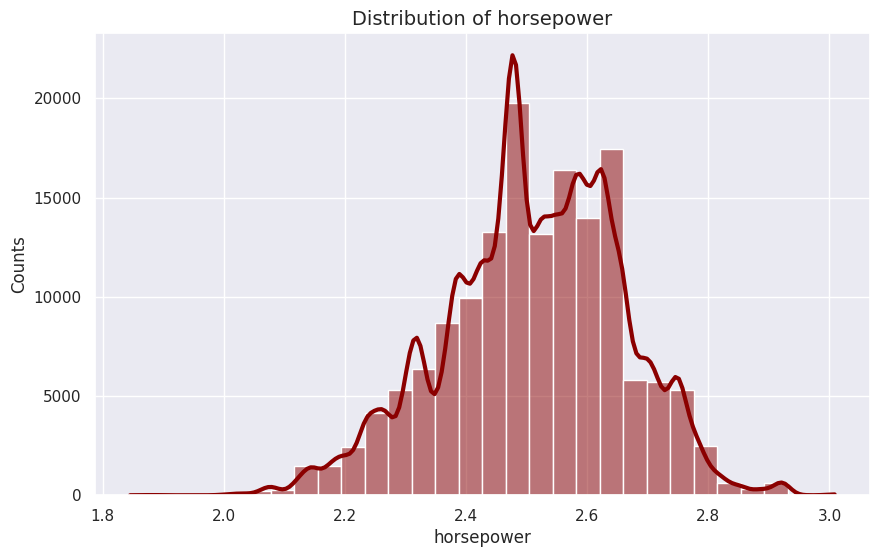

In [29]:
plot_num_distribution(df_train, 'horsepower')

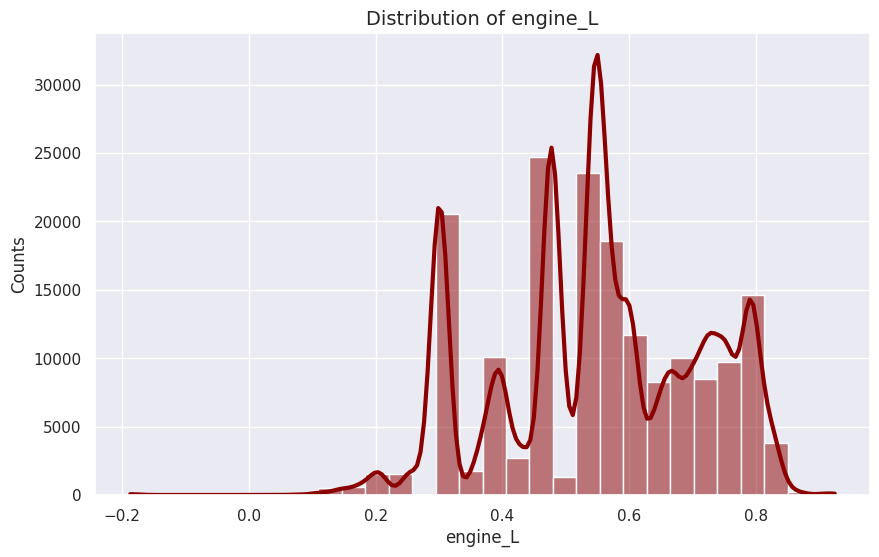

In [30]:
plot_num_distribution(df_train, 'engine_L')

In [31]:
def cleaning(data):
  df = data.copy()
  cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
                'int_col', 'accident']

  for feature in ['fuel_type', 'accident', 'clean_title', 'engine', 'transmission', 'ext_col', 'int_col']:
    df[feature] = df[feature].fillna("no_entry")

  df['horsepower'] = df['horsepower'].fillna(-1)
  df['engine_L'] = df['engine_L'].fillna(-1)

  df['clean_title'] = np.where(df['clean_title']== 'Yes',1,0).astype('int16')
  df['mileage'] = df['milage']//100
  for feature in cat_cols:
        df[feature] = df[feature].astype('category')
  df.drop(['id'], axis=1, inplace=True)

  return df

In [32]:
feat_cols = df_test.columns.to_list()
data_concat = cleaning(pd.concat([df_train[feat_cols], df_test]))
data_train = data_concat[:len(df_train)].copy()
data_train['price']=df_train['price']
data_test = data_concat[len(df_train):]
cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
                'int_col', 'accident', 'model_year','mileage',
           ]
num_cols = ['milage', 'horsepower', 'engine_L']

In [33]:
data_train['clean_title'].unique()

array([1, 0], dtype=int16)

In [34]:
data_train.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [35]:
data_test.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [ ]:
%%capture
!pip install ydata-profiling
from ydata_profiling import ProfileReport

In [ ]:
from IPython.display import HTML # import the HTML object

In [ ]:
profile_change = ProfileReport(data_train,title="Used Cars. Profiling Report", explorative=True,)
profile_change.to_file("output_change.html")
HTML(filename='output_change.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:04<00:00,  3.44it/s]
/usr/local/lib/python3.11/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[9 9 9 ... 9 0 9]' has dtype incompatible with int16, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Modelado

In [36]:
# Importaciones necesarias para todos los modelos
! pip install category_encoders
import pandas as pd
import numpy as np
import datetime
import joblib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import LinearSVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Instalar bibliotecas necesarias si no están disponibles
try:
    import category_encoders
except ImportError:
    !pip install category_encoders

try:
    import catboost
    from catboost import CatBoostRegressor
except ImportError:
    !pip install catboost
    from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.8 MB/s eta 0:00:00


In [37]:
# Función de validación cruzada mejorada
def crossvalidate(model, data_train, data_test, n_splits=5, seed=42, n_bins=10, model_name="Modelo"):
    """
    Realiza validación cruzada estratificada y devuelve predicciones, scores y métricas

    Args:
        model: Modelo a evaluar
        data_train: DataFrame de entrenamiento
        data_test: DataFrame de test
        n_splits: Número de folds
        seed: Semilla aleatoria
        n_bins: Número de bins para estratificación
        model_name: Nombre del modelo para los logs

    Returns:
        tuple: (predicciones de test, predicciones out-of-fold, rmse, r2, diferencia rmse)
    """
    start_time = datetime.datetime.now()
    print(f"\n🔹 Evaluando: {model_name} 🔹")

    y = data_train["price"]
    X = data_train.drop(columns="price")

    # Estratificación por percentiles del target
    y_binned = pd.qcut(y, q=n_bins, duplicates='drop', labels=False)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    rmse_scores = []
    r2_scores = []
    train_rmse_scores = []
    oof_preds = np.zeros(len(data_train))

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y_binned)):
        print(f"🔁 Fold {fold + 1}/{n_splits}")

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]

        # Ajustar el modelo
        model.fit(X_train, y_train)

        # Predicciones para validación
        preds_valid = model.predict(X_valid)
        oof_preds[valid_idx] = preds_valid

        # Calcular métricas de validación
        rmse_valid = np.sqrt(mean_squared_error(y_valid, preds_valid))
        r2_valid = r2_score(y_valid, preds_valid)
        rmse_scores.append(rmse_valid)
        r2_scores.append(r2_valid)

        # Calcular métricas de entrenamiento
        preds_train = model.predict(X_train)
        rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
        train_rmse_scores.append(rmse_train)

        print(f"📉 Fold {fold + 1} - RMSE validación: {rmse_valid:.2f}, R² validación: {r2_valid:.4f}")
        print(f"📊 RMSE entrenamiento: {rmse_train:.2f}")

    end_time = datetime.datetime.now()
    print(f"✅ Cross-validation completada en: {end_time - start_time}")

    # Calcular promedios
    avg_rmse_valid = np.mean(rmse_scores)
    avg_rmse_train = np.mean(train_rmse_scores)
    avg_r2_valid = np.mean(r2_scores)

    # Calcular overfitting
    rmse_diff = abs(avg_rmse_train - avg_rmse_valid)
    rmse_diff_pct = rmse_diff / avg_rmse_valid * 100

    print(f"📊 Promedio RMSE en entrenamiento: {avg_rmse_train:.2f}")
    print(f"📊 Promedio RMSE en validación: {avg_rmse_valid:.2f}")
    print(f"📊 Promedio R² en validación: {avg_r2_valid:.4f}")
    print(f"📊 Diferencia de RMSE: {rmse_diff:.2f} ({rmse_diff_pct:.2f}%)")

    # Verificar overfitting
    if rmse_diff / avg_rmse_valid <= 0.05:
        print("✅ Overfitting inferior al 5%")
    else:
        print("⚠️ Overfitting superior al 5%, puede haber sobreajuste")

    # Predicciones finales en test
    test_preds = model.predict(data_test)

    return test_preds, oof_preds, avg_rmse_valid, avg_r2_valid, rmse_diff_pct


In [38]:
# Función para crear tabla comparativa
def create_comparison_table(results):
    """
    Crea un DataFrame comparativo de todos los modelos

    Args:
        results: Diccionario con resultados de los modelos

    Returns:
        DataFrame: Tabla comparativa
    """
    comparison_data = []

    for model_name, metrics in results.items():
        comparison_data.append({
            'Modelo': model_name,
            'RMSE': metrics['rmse'],
            'R²': metrics['r2'],
            'Overfitting (%)': metrics['diff_pct']
        })

    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('RMSE')

    return comparison_df

In [39]:
# Función para exportar el mejor modelo
def export_best_model(model, model_name):
    """
    Exporta el mejor modelo usando joblib

    Args:
        model: Modelo a exportar
        model_name: Nombre del modelo
    """
    filename = f"{model_name.lower()}_best_model.pkl"
    joblib.dump(model, filename)
    print(f"✅ Modelo '{model_name}' exportado como '{filename}'")
    return filename

In [40]:
# Función para visualizar comparativa de modelos
def plot_model_comparison(comparison_df):
    """
    Genera visualizaciones comparativas de los modelos

    Args:
        comparison_df: DataFrame con comparativa de modelos
    """
    # Configuración de la figura
    plt.figure(figsize=(12, 6))

    # Gráfico de barras para RMSE
    plt.subplot(1, 2, 1)
    sns.barplot(x='Modelo', y='RMSE', data=comparison_df, palette='viridis')
    plt.title('Comparativa de RMSE por Modelo')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Gráfico de barras para R²
    plt.subplot(1, 2, 2)
    sns.barplot(x='Modelo', y='R²', data=comparison_df, palette='viridis')
    plt.title('Comparativa de R² por Modelo')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig('modelo_comparativa.png')
    print("✅ Gráficos guardados como 'modelo_comparativa.png'")


In [41]:
def evaluate_svr(data_train, data_test):
    """Evalúa el modelo SVR"""
    cols = ['milage', 'model_year', 'model', 'brand',
            'engine', 'engine_L', 'ext_col', 'fuel_type',
            'accident', 'int_col', 'clean_title', 'mileage',
            'horsepower', 'price']

    X_test_cols = [c for c in cols if c != 'price']

    cat_features = ['accident', 'brand', 'model_year', 'fuel_type', 'model',
                    'engine', 'ext_col', 'int_col', 'clean_title']

    svr_params = {
        'C': 1000,
        'epsilon': 0.2,
        'max_iter': 20000,
        'tol': 0.0005,
        'random_state': 42,
    }

    model = make_pipeline(
        TargetEncoder(cols=cat_features, smoothing=10, min_samples_leaf=2),
        StandardScaler().set_output(transform='pandas'),
        LinearSVR(**svr_params)
    )

    test_preds, oof_preds, rmse, r2, diff_pct = crossvalidate(
        model,
        data_train[cols],
        data_test[X_test_cols],
        model_name="SVR"
    )

    return {
        'model': model,
        'test_preds': test_preds,
        'oof_preds': oof_preds,
        'rmse': rmse,
        'r2': r2,
        'diff_pct': diff_pct
    }

In [42]:
def evaluate_gradient_boosting(data_train, data_test):
    """Evalúa el modelo Gradient Boosting"""
    cols = ['milage', 'model_year', 'model', 'brand',
            'engine', 'engine_L', 'ext_col', 'fuel_type',
            'accident', 'int_col', 'clean_title', 'mileage',
            'horsepower', 'price']

    X_test_cols = [c for c in cols if c != 'price']

    cat_features = ['accident', 'brand', 'model_year', 'fuel_type', 'model',
                   'engine', 'ext_col', 'int_col', 'clean_title']

    gb_params = {
        'n_estimators': 200,
        'learning_rate': 0.02,
        'max_depth': 4,
        'min_samples_split': 10,
        'min_samples_leaf': 4,
        'subsample': 0.8,
        'random_state': 42
    }

    model = make_pipeline(
        TargetEncoder(cols=cat_features, smoothing=10, min_samples_leaf=2),
        StandardScaler().set_output(transform='pandas'),
        GradientBoostingRegressor(**gb_params)
    )

    test_preds, oof_preds, rmse, r2, diff_pct = crossvalidate(
        model,
        data_train[cols],
        data_test[X_test_cols],
        model_name="GradientBoosting"
    )

    return {
        'model': model,
        'test_preds': test_preds,
        'oof_preds': oof_preds,
        'rmse': rmse,
        'r2': r2,
        'diff_pct': diff_pct
    }

In [43]:
def evaluate_catboost(data_train, data_test):
    """Evalúa el modelo CatBoost con manejo adecuado de features categóricas"""
    cols = ['milage', 'model_year', 'model', 'brand',
            'engine', 'engine_L', 'ext_col', 'fuel_type',
            'accident', 'int_col', 'clean_title', 'mileage',
            'horsepower', 'price']

    X_test_cols = [c for c in cols if c != 'price']

    # Para CatBoost, necesitamos asegurarnos que 'engine_L' sea tratada como numérica
    # Primero creamos una copia de los datos para no modificar los originales
    train_copy = data_train[cols].copy()
    test_copy = data_test[X_test_cols].copy()

    # Definimos las características categóricas excluyendo 'engine_L'
    cat_features = ['brand', 'model', 'fuel_type', 'engine',
                    'ext_col', 'int_col', 'accident', 'model_year', 'clean_title']

    # Obtenemos los índices de las columnas categóricas
    cat_features_idx = [train_copy.columns.get_loc(c) for c in cat_features if c in train_copy.columns]

    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3,
        random_strength=1,
        bagging_temperature=1,
        border_count=254,
        cat_features=cat_features_idx,
        early_stopping_rounds=50,
        verbose=100,
        random_state=42
    )

    test_preds, oof_preds, rmse, r2, diff_pct = crossvalidate(
        model,
        train_copy,
        test_copy,
        model_name="CatBoost"
    )

    return {
        'model': model,
        'test_preds': test_preds,
        'oof_preds': oof_preds,
        'rmse': rmse,
        'r2': r2,
        'diff_pct': diff_pct
    }

In [44]:
def evaluate_decision_tree(data_train, data_test):
    """Evalúa el modelo Decision Tree"""
    cols = ['milage', 'model_year', 'model', 'brand',
            'engine', 'engine_L', 'ext_col', 'fuel_type',
            'accident', 'int_col', 'clean_title', 'mileage',
            'horsepower', 'price']

    X_test_cols = [c for c in cols if c != 'price']

    # Columnas categóricas y numéricas
    cat_features = ['brand', 'model', 'fuel_type', 'engine',
                    'ext_col', 'int_col', 'accident', 'model_year', 'clean_title']
    num_features = ['milage', 'engine_L', 'mileage', 'horsepower']

    tree_preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ])

    model = Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('regressor', DecisionTreeRegressor(
            max_depth=6,
            min_samples_leaf=20,
            min_samples_split=60,
            max_features='sqrt',
            random_state=42
        ))
    ])

    test_preds, oof_preds, rmse, r2, diff_pct = crossvalidate(
        model,
        data_train[cols],
        data_test[X_test_cols],
        model_name="DecisionTree"
    )

    return {
        'model': model,
        'test_preds': test_preds,
        'oof_preds': oof_preds,
        'rmse': rmse,
        'r2': r2,
        'diff_pct': diff_pct
    }


In [45]:
# Diccionario para almacenar resultados
results = {}

## SVR

In [46]:
# Evaluar SVR
print("\n📊 Evaluando modelo: SVR")
results['SVR'] = evaluate_svr(data_train, data_test)


📊 Evaluando modelo: SVR

🔹 Evaluando: SVR 🔹
🔁 Fold 1/5
📉 Fold 1 - RMSE validación: 67658.71, R² validación: 0.1252
📊 RMSE entrenamiento: 76018.73
🔁 Fold 2/5
📉 Fold 2 - RMSE validación: 71964.02, R² validación: 0.1109
📊 RMSE entrenamiento: 74950.49
🔁 Fold 3/5
📉 Fold 3 - RMSE validación: 76811.21, R² validación: 0.0952
📊 RMSE entrenamiento: 73903.79
🔁 Fold 4/5
📉 Fold 4 - RMSE validación: 78335.37, R² validación: 0.0918
📊 RMSE entrenamiento: 73482.61
🔁 Fold 5/5
📉 Fold 5 - RMSE validación: 78059.41, R² validación: 0.0942
📊 RMSE entrenamiento: 73589.11
✅ Cross-validation completada en: 0:00:28.194109
📊 Promedio RMSE en entrenamiento: 74388.95
📊 Promedio RMSE en validación: 74565.75
📊 Promedio R² en validación: 0.1035
📊 Diferencia de RMSE: 176.80 (0.24%)
✅ Overfitting inferior al 5%


## Gradient Boosting

In [47]:
# Evaluar Gradient Boosting
print("\n📊 Evaluando modelo: GradientBoosting")
results['GradientBoosting'] = evaluate_gradient_boosting(data_train, data_test)


📊 Evaluando modelo: GradientBoosting

🔹 Evaluando: GradientBoosting 🔹
🔁 Fold 1/5
📉 Fold 1 - RMSE validación: 65833.30, R² validación: 0.1718
📊 RMSE entrenamiento: 72358.96
🔁 Fold 2/5
📉 Fold 2 - RMSE validación: 70963.58, R² validación: 0.1355
📊 RMSE entrenamiento: 71158.92
🔁 Fold 3/5
📉 Fold 3 - RMSE validación: 75633.88, R² validación: 0.1227
📊 RMSE entrenamiento: 69858.19
🔁 Fold 4/5
📉 Fold 4 - RMSE validación: 76873.78, R² validación: 0.1254
📊 RMSE entrenamiento: 69620.63
🔁 Fold 5/5
📉 Fold 5 - RMSE validación: 76657.30, R² validación: 0.1265
📊 RMSE entrenamiento: 69546.17
✅ Cross-validation completada en: 0:06:08.922246
📊 Promedio RMSE en entrenamiento: 70508.58
📊 Promedio RMSE en validación: 73192.37
📊 Promedio R² en validación: 0.1364
📊 Diferencia de RMSE: 2683.79 (3.67%)
✅ Overfitting inferior al 5%


## Cat Boost

In [48]:
# Evaluar CatBoost
print("\n📊 Evaluando modelo: CatBoost")
results['CatBoost'] = evaluate_catboost(data_train, data_test)


📊 Evaluando modelo: CatBoost

🔹 Evaluando: CatBoost 🔹
🔁 Fold 1/5
0:	learn: 80055.6111733	total: 448ms	remaining: 3m 43s
100:	learn: 74126.1956995	total: 34s	remaining: 2m 14s
200:	learn: 73538.4589369	total: 1m 7s	remaining: 1m 41s
300:	learn: 73145.1942989	total: 1m 40s	remaining: 1m 6s
400:	learn: 72869.5168959	total: 2m 10s	remaining: 32.2s
499:	learn: 72641.4324419	total: 2m 37s	remaining: 0us
📉 Fold 1 - RMSE validación: 65642.12, R² validación: 0.1766
📊 RMSE entrenamiento: 73550.13
🔁 Fold 2/5
0:	learn: 79137.2335447	total: 334ms	remaining: 2m 46s
100:	learn: 72959.8574722	total: 33s	remaining: 2m 10s
200:	learn: 72389.0296804	total: 1m 3s	remaining: 1m 34s
300:	learn: 72068.6969835	total: 1m 34s	remaining: 1m 2s
400:	learn: 71776.6688664	total: 2m 2s	remaining: 30.2s
499:	learn: 71573.0266248	total: 2m 28s	remaining: 0us
📉 Fold 2 - RMSE validación: 70264.07, R² validación: 0.1524
📊 RMSE entrenamiento: 72362.35
🔁 Fold 3/5
0:	learn: 78017.9053524	total: 293ms	remaining: 2m 26s
100:

## Decision Tree

In [49]:
# Evaluar Decision Tree
print("\n📊 Evaluando modelo: DecisionTree")
results['DecisionTree'] = evaluate_decision_tree(data_train, data_test)


📊 Evaluando modelo: DecisionTree

🔹 Evaluando: DecisionTree 🔹
🔁 Fold 1/5
📉 Fold 1 - RMSE validación: 68911.46, R² validación: 0.0925
📊 RMSE entrenamiento: 77148.46
🔁 Fold 2/5
📉 Fold 2 - RMSE validación: 74018.67, R² validación: 0.0594
📊 RMSE entrenamiento: 77195.58
🔁 Fold 3/5
📉 Fold 3 - RMSE validación: 78603.65, R² validación: 0.0525
📊 RMSE entrenamiento: 76076.04
🔁 Fold 4/5
📉 Fold 4 - RMSE validación: 79149.46, R² validación: 0.0728
📊 RMSE entrenamiento: 74657.46
🔁 Fold 5/5
📉 Fold 5 - RMSE validación: 80758.43, R² validación: 0.0305
📊 RMSE entrenamiento: 76707.03
✅ Cross-validation completada en: 0:01:49.410635
📊 Promedio RMSE en entrenamiento: 76356.92
📊 Promedio RMSE en validación: 76288.33
📊 Promedio R² en validación: 0.0615
📊 Diferencia de RMSE: 68.58 (0.09%)
✅ Overfitting inferior al 5%


## Best Model

In [50]:
# Encontrar el mejor modelo
best_model = None
best_model_name = None
best_rmse = float('inf')

for model_name, metrics in results.items():
    if metrics['rmse'] < best_rmse:
        best_rmse = metrics['rmse']
        best_model = metrics['model']
        best_model_name = model_name



🔸 Tabla Comparativa de Modelos 🔸
             Modelo          RMSE        R²  Overfitting (%)
2          CatBoost  72641.327231  0.149236         1.231864
1  GradientBoosting  73192.368936  0.136357         3.666767
0               SVR  74565.745984  0.103465         0.237101
3      DecisionTree  76288.334028  0.061544         0.089900


<ipython-input-40-eaf67af46702>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE', data=comparison_df, palette='viridis')
<ipython-input-40-eaf67af46702>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=comparison_df, palette='viridis')


✅ Gráficos guardados como 'modelo_comparativa.png'


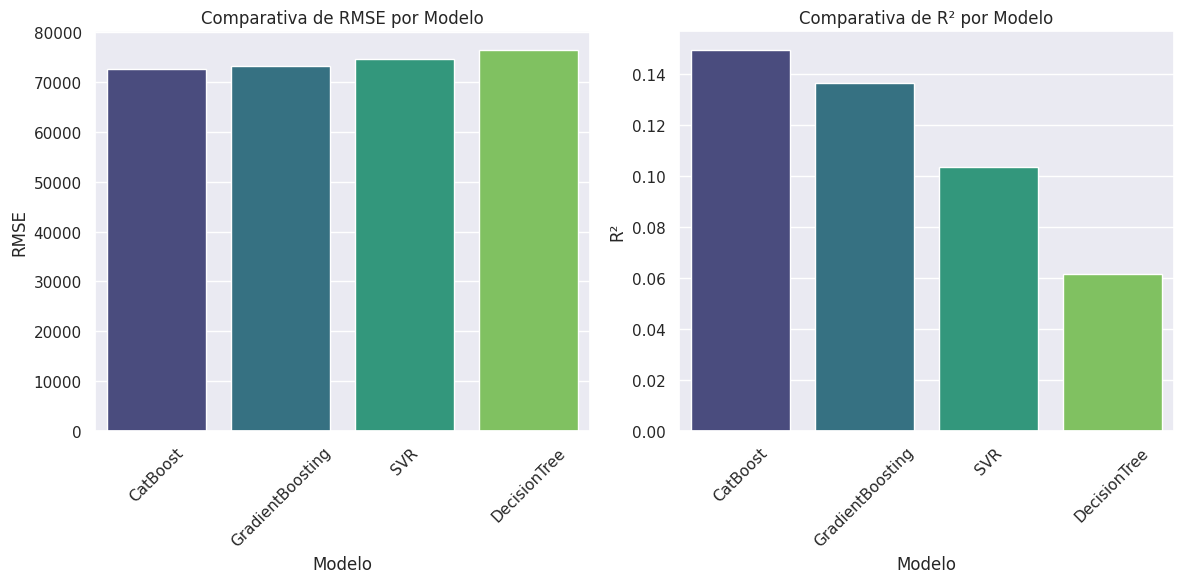

In [51]:
# Crear tabla comparativa
comparison_df = create_comparison_table(results)
print("\n🔸 Tabla Comparativa de Modelos 🔸")
print(comparison_df)

# Visualizar comparativa
plot_model_comparison(comparison_df)

In [52]:
# Exportar mejor modelo
if best_model is not None:
    model_filename = export_best_model(best_model, best_model_name)
    print(f"\n🏆 El mejor modelo es: {best_model_name} (RMSE: {results[best_model_name]['rmse']:.2f})")
    print(f"🔗 Guardado como: {model_filename}")
else:
    print("\n⚠️ No se pudo determinar el mejor modelo")

✅ Modelo 'CatBoost' exportado como 'catboost_best_model.pkl'

🏆 El mejor modelo es: CatBoost (RMSE: 72641.33)
🔗 Guardado como: catboost_best_model.pkl


## Post Processing

In [54]:
test_pred_catboost = results['CatBoost']['test_preds']
test_pred_catboost = np.clip(test_pred_catboost, 2000, 2954083)

## CSV and PKL

In [55]:
df_sub['price'] = test_pred_catboost
df_sub.to_csv("submission.csv",index=None)
df_sub.head()

,id,price
0,188533,17398.615287
1,188534,79167.243568
2,188535,58685.288205
3,188536,28494.729371
4,188537,30030.263888


In [56]:
model_filename = export_best_model(best_model, best_model_name)
print(f"🔗 Guardado como: {model_filename}")

✅ Modelo 'CatBoost' exportado como 'catboost_best_model.pkl'
🔗 Guardado como: catboost_best_model.pkl
